# EpiCite · Notebook 05 — Training Pipeline v3

**Group 12 — AIT NLP** · Biraj Koirala · Longfei Shi

---

## What changed from Notebook 04

This notebook supersedes the Stage 1 v2 + Stage 2 Late-Fusion pipeline from Notebook 04.
Eight design decisions were made in advance; this notebook implements all of them.

| # | Decision area | Choice |
|---|---|---|
| Q1 | Feature engineering | Two-track: baseline (18 feat.) + v2 (~22 feat. with new families & token-rates) |
| Q2 | Training schedule | Generous max-epochs, patience=2, cosine annealing |
| Q3 | Class imbalance | Focal loss (γ=2) + WeightedRandomSampler; augmentation togglable |
| Q4 | Data | Add IBM Evidence + IBM CDC; skip FEVER; dual test sets |
| Q5 | Interpretability hooks | Save artefacts needed by the evaluation notebook |
| Q6 | Use cases | MCP-ready predict function exported |
| Q7 | Error analysis | Write per-prediction outputs for the evaluation notebook |
| Q8 | Qwen benchmark | Test indices saved so Qwen sees the same examples |

**Outputs of this notebook** (all placed in `output/` and consumed by Notebook 06):

- `stage1v3_focal_best.pt` — Stage 1 v3 checkpoint (focal + IBM-augmented)
- `stage1v3_test_predictions.csv` — per-row predictions for error analysis
- `stage1v3_ibm_test_predictions.csv` — held-out IBM test predictions
- `stage2v3_late_fusion_best.pt` — Stage 2 v3 checkpoint (full Late-Fusion)
- `stage2v3_baseline_18feat_best.pt` — baseline v3 for the v1-vs-v2 ablation
- `stage2v3_no_epi_best.pt` — ablation with epistemic features removed (Q5 track 3)
- `stage2v3_test_predictions.csv` — per-row predictions for error analysis
- `stage2v3_engineered_features.csv` — 22-dim feature matrix (for SHAP / MI)
- `stage2v3_metadata.json` — metric summary, config, file paths


---
## Section 0 · Setup, Configuration, Toggles

All shared infrastructure — imports, label maps, toggles, device check — lives here.
The `CONFIG` dict near the top is the single source of truth: change a value there,
re-run the section, everything downstream picks it up.


In [1]:
# Uncomment on first run.
# !pip install -q transformers datasets torch scikit-learn shap captum lime spacy tqdm
# !python -m spacy download en_core_web_sm -q

In [2]:
import os, re, json, time, math, warnings, pickle, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import spacy
from spacy.matcher import Matcher

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from transformers import (
    DistilBertTokenizerFast,
    DistilBertModel,
    DistilBertForSequenceClassification,
    get_cosine_schedule_with_warmup,
)
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    accuracy_score, confusion_matrix, brier_score_loss,
    average_precision_score, precision_recall_curve,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
sns.set_style("whitegrid")

In [3]:
# ═══════════════════════════════════════════════════════════════
# CONFIG — single source of truth for the whole notebook
# ═══════════════════════════════════════════════════════════════
CONFIG = {
    # ── Reproducibility ───────────────────────────────────────────
    "seed": 42,

    # ── Stage 1 corpus ────────────────────────────────────────────
    "stage1_csv":      "output/stage1_combined.csv",  # original 4-class corpus
    "ibm_evidence_csv": "data/ibm_evidence.csv",      # see Section 1.2 for format
    "ibm_cdc_csv":      "data/ibm_cdc.csv",
    "use_ibm":         True,

    # ── Class imbalance toolkit ───────────────────────────────────
    "loss_type":              "focal",   # "focal" | "ce_weighted" | "ce_uniform"
    "focal_gamma":            2.0,
    "use_weighted_sampler":   True,
    "use_augmentation":       False,     # PLAN B toggle — see Section 1.4
    "augmentation_target":    1500,      # synthetic Evidence target if enabled
    "augmentation_method":    "backtranslation",  # "backtranslation" | "llm"

    # ── Stage 1 training ──────────────────────────────────────────
    "s1_max_len":          128,
    "s1_batch_size":       32,
    "s1_max_epochs":       8,
    "s1_patience":         2,
    "s1_lr":               2e-5,
    "s1_warmup_frac":      0.1,

    # ── Stage 2 dataset ───────────────────────────────────────────
    "wikisqe_target_per_class": 75_000,

    # ── Stage 2 training (cosine annealing across all phases) ─────
    "s2_max_len":          128,
    "s2_batch_size":       32,
    "s2_p1_max_epochs":    5,
    "s2_p2_max_epochs":    8,
    "s2_p3_max_epochs":    5,
    "s2_patience":         2,
    "s2_p1_lr":            1e-3,
    "s2_p2_lr":            2e-5,
    "s2_p3_lr":            5e-6,

    # ── Output paths ──────────────────────────────────────────────
    "out_dir":             "output",
    "data_dir":            "data",
}

random.seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
torch.manual_seed(CONFIG["seed"])
torch.cuda.manual_seed_all(CONFIG["seed"])
SEED = CONFIG["seed"]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU   :", torch.cuda.get_device_name(0))

os.makedirs(CONFIG["out_dir"], exist_ok=True)
os.makedirs(CONFIG["data_dir"], exist_ok=True)

Device: cuda
GPU   : NVIDIA GeForce RTX 2080 Ti


In [4]:
# Label spaces — kept identical to Notebook 04 so checkpoints remain compatible.
CLASSES    = ["Claim", "Evidence", "Opinion", "Background"]
LABEL2ID   = {c: i for i, c in enumerate(CLASSES)}
ID2LABEL   = {i: c for c, i in LABEL2ID.items()}
NUM_CLASSES = len(CLASSES)

CLASS_COLORS = {
    "Claim":      "#4C72B0",
    "Evidence":   "#55A868",
    "Opinion":    "#C44E52",
    "Background": "#8172B2",
}

MODEL_NAME = "distilbert-base-uncased"
print(f"Classes : {CLASSES}")
print(f"Backbone: {MODEL_NAME}")

Classes : ['Claim', 'Evidence', 'Opinion', 'Background']
Backbone: distilbert-base-uncased


---
## Section 0.5 · spaCy Feature Extractor (Baseline + v2)

The baseline (12 features) is the same as Notebook 04. The **v2 extractor** adds the
six new families chosen in Q1: numerical content, named-entity counts, universal/
superlative quantifiers, reporting verbs, causal markers, and syntactic complexity.

Both extractors return per-token-rate-normalised values where the original would
have been a raw count. This makes features length-invariant.


In [5]:
nlp = spacy.load("en_core_web_sm")

# ─── Baseline lexicons (identical to Notebook 04) ──────────────────
HEDGE_VERBS = ["seem","seems","seemed","appear","appears","appeared",
               "suggest","suggests","suggested","indicate","indicates","indicated",
               "propose","tend","tends","tended","believe","believes","believed",
               "assume","assumes","assumed","speculate","speculates","speculated",
               "hypothesize","estimate","estimates","estimated","report","reports","reported"]
HEDGE_AUX   = ["may","might","could","would","should","can"]
HEDGE_ADV   = ["possibly","probably","perhaps","allegedly","reportedly","presumably",
               "arguably","apparently","supposedly","ostensibly","likely","unlikely",
               "generally","typically","usually","often","sometimes","occasionally",
               "roughly","approximately","potentially","conceivably","purportedly"]
VAGUE_QUANT = ["some","many","several","a lot","most","much","few","various",
               "numerous","plenty","considerable","significant"]
BOOSTERS    = ["clearly","obviously","certainly","definitely","undoubtedly","surely"]
SUBJECTIVE  = ["I","we","my","our","myself","ourselves","me","us"]

# ─── v2 ADDITIONS (the new feature families from Q1) ───────────────

# Family 3: universal & superlative quantifiers
UNIVERSAL_QUANT  = ["all","every","any","always","never","none","no one",
                    "everyone","everywhere","everything","nothing"]
SUPERLATIVE_LEX  = ["first","largest","smallest","best","worst","most","least",
                    "highest","lowest","biggest","greatest","oldest","newest",
                    "fastest","slowest","strongest","weakest","only","unique"]

# Family 4: reporting verbs (vs assertive verbs; reporting → less likely to need cite,
# raw assertion → more likely)
REPORTING_VERBS  = ["according","reports","reported","stated","states","said",
                    "claims","claimed","argues","argued","wrote","writes","cites",
                    "cited","notes","noted","observed","observes"]

# Family 5: causal claim markers (causal claims often need evidence)
CAUSAL_MARKERS   = ["causes","caused","leads to","results in","because","therefore",
                    "thus","consequently","hence","due to","triggers","triggered",
                    "produces","produced","contributes to"]

def _to_set_lower(words):
    return {w.lower() for w in words}

LEX = {
    "hedge_verbs":      _to_set_lower(HEDGE_VERBS),
    "hedge_aux":        _to_set_lower(HEDGE_AUX),
    "hedge_adv":        _to_set_lower(HEDGE_ADV),
    "vague_quant":      _to_set_lower(VAGUE_QUANT),
    "boosters":         _to_set_lower(BOOSTERS),
    "subjective":       _to_set_lower(SUBJECTIVE),
    "universal_quant":  _to_set_lower(UNIVERSAL_QUANT),
    "superlative":      _to_set_lower(SUPERLATIVE_LEX),
    "reporting_verbs":  _to_set_lower(REPORTING_VERBS),
    "causal_markers":   _to_set_lower(CAUSAL_MARKERS),
}

print("Lexicons loaded:")
for k, v in LEX.items():
    print(f"  {k:<18} {len(v):>4} terms")

Lexicons loaded:
  hedge_verbs          32 terms
  hedge_aux             6 terms
  hedge_adv            23 terms
  vague_quant          12 terms
  boosters              6 terms
  subjective            8 terms
  universal_quant      11 terms
  superlative          19 terms
  reporting_verbs      18 terms
  causal_markers       15 terms


In [6]:
# ═════════════════════════════════════════════════════════════════
# Feature extraction — returns BOTH the baseline vector and the v2 vector
# in a single pass. Token-rate normalisation everywhere except length itself.
# ═════════════════════════════════════════════════════════════════

# Number-pattern regexes for the numerical-content family
RE_PERCENT  = re.compile(r"\d+(?:\.\d+)?\s*%")
RE_DOLLAR   = re.compile(r"\$\s*\d")
RE_YEAR     = re.compile(r"\b(?:19|20)\d{2}\b")
RE_DIGIT    = re.compile(r"\b\d+(?:[.,]\d+)*\b")
RE_INLINE_CITE = re.compile(r"\[\s*\d+\s*\]")  # already-existing [1] markers

# Baseline columns (matches Notebook 04 ordering)
BASELINE_COLS = [
    "n_hedge_verbs","n_hedge_aux","n_hedge_adv","n_vague_quant",
    "n_boosters","n_subjective_pron","n_negations","n_passive",
    "n_proper_nouns","n_numbers","n_modals","sentence_length",  # raw count kept
]

# v2 columns — note token-rate normalisation suffix _r
V2_NEW_COLS = [
    # Numerical/statistical content (Family 1)
    "rate_percent","rate_dollar","rate_year","rate_digit","rate_inline_cite",
    # Named entity counts (Family 2)
    "rate_ent_person","rate_ent_org","rate_ent_gpe","rate_ent_date","rate_ent_total",
    # Universal/superlative (Family 3)
    "rate_universal_quant","rate_superlative",
    # Reporting verbs (Family 4)
    "rate_reporting_verbs",
    # Causal markers (Family 5)
    "rate_causal_markers",
    # Syntactic complexity (Family 6)
    "dep_tree_depth","n_clauses","noun_verb_ratio",
]

V2_FULL_COLS = BASELINE_COLS + V2_NEW_COLS  # 12 + 17 = 29 (we'll later add epi probs)

def _dep_depth(token):
    """Recursive dependency-tree depth from this token down."""
    if not list(token.children):
        return 1
    return 1 + max(_dep_depth(c) for c in token.children)

def extract_features_full(text: str) -> dict:
    """Return BOTH baseline-12 and v2-17 features in one dict.

    Token-rate features divide by max(n_tokens, 1) so they are length-invariant.
    sentence_length is kept as a raw count (Q1 decision: keep in baseline).
    """
    doc = nlp(str(text))
    toks = [t for t in doc if not t.is_space]
    n = max(len(toks), 1)
    lower = [t.text.lower() for t in toks]
    out = {}

    # ── Baseline 12 (raw counts, matching Notebook 04) ──
    out["n_hedge_verbs"]     = sum(1 for w in lower if w in LEX["hedge_verbs"])
    out["n_hedge_aux"]       = sum(1 for w in lower if w in LEX["hedge_aux"])
    out["n_hedge_adv"]       = sum(1 for w in lower if w in LEX["hedge_adv"])
    out["n_vague_quant"]     = sum(1 for w in lower if w in LEX["vague_quant"])
    out["n_boosters"]        = sum(1 for w in lower if w in LEX["boosters"])
    out["n_subjective_pron"] = sum(1 for w in lower if w in LEX["subjective"])
    out["n_negations"]       = sum(1 for t in doc if t.dep_ == "neg")
    out["n_passive"]         = sum(1 for t in doc if t.dep_ == "auxpass")
    out["n_proper_nouns"]    = sum(1 for t in doc if t.pos_ == "PROPN")
    out["n_numbers"]         = sum(1 for t in doc if t.like_num)
    out["n_modals"]          = sum(1 for t in doc if t.tag_ == "MD")
    out["sentence_length"]   = n  # raw token count

    # ── v2 NEW: Family 1 numerical content (regex on raw text) ──
    out["rate_percent"]      = len(RE_PERCENT.findall(text)) / n
    out["rate_dollar"]       = len(RE_DOLLAR.findall(text)) / n
    out["rate_year"]         = len(RE_YEAR.findall(text)) / n
    out["rate_digit"]        = len(RE_DIGIT.findall(text)) / n
    out["rate_inline_cite"]  = len(RE_INLINE_CITE.findall(text)) / n

    # ── v2 NEW: Family 2 named entities ──
    ent_labels = [e.label_ for e in doc.ents]
    out["rate_ent_person"]   = ent_labels.count("PERSON") / n
    out["rate_ent_org"]      = ent_labels.count("ORG")    / n
    out["rate_ent_gpe"]      = ent_labels.count("GPE")    / n
    out["rate_ent_date"]     = ent_labels.count("DATE")   / n
    out["rate_ent_total"]    = len(ent_labels)            / n

    # ── v2 NEW: Family 3 universal & superlative ──
    out["rate_universal_quant"] = sum(1 for w in lower if w in LEX["universal_quant"]) / n
    out["rate_superlative"]     = sum(1 for w in lower if w in LEX["superlative"]) / n

    # ── v2 NEW: Family 4 reporting verbs ──
    out["rate_reporting_verbs"] = sum(1 for w in lower if w in LEX["reporting_verbs"]) / n

    # ── v2 NEW: Family 5 causal markers ──
    # need raw text scan because some are multi-word
    text_lower = text.lower()
    causal_count = sum(text_lower.count(m) for m in LEX["causal_markers"])
    out["rate_causal_markers"]  = causal_count / n

    # ── v2 NEW: Family 6 syntactic complexity ──
    roots = [t for t in doc if t.dep_ == "ROOT"]
    out["dep_tree_depth"] = max((_dep_depth(r) for r in roots), default=1)
    out["n_clauses"]      = sum(1 for t in doc if t.dep_ in {"ccomp","xcomp","advcl","relcl"}) + 1
    n_noun  = sum(1 for t in doc if t.pos_ in {"NOUN","PROPN"})
    n_verb  = sum(1 for t in doc if t.pos_ == "VERB")
    out["noun_verb_ratio"] = n_noun / max(n_verb, 1)

    return out

# Smoke-test on one sentence
demo = ("In 2019, the WHO reported that approximately 23% of patients with diabetes "
        "showed improvement after treatment.")
demo_feat = extract_features_full(demo)
print(f"v2 feature vector ({len(V2_FULL_COLS)} dims):")
for c in V2_FULL_COLS:
    print(f"  {c:<25} {demo_feat[c]:.4f}")

v2 feature vector (29 dims):
  n_hedge_verbs             1.0000
  n_hedge_aux               0.0000
  n_hedge_adv               1.0000
  n_vague_quant             0.0000
  n_boosters                0.0000
  n_subjective_pron         0.0000
  n_negations               0.0000
  n_passive                 0.0000
  n_proper_nouns            1.0000
  n_numbers                 2.0000
  n_modals                  0.0000
  sentence_length           19.0000
  rate_percent              0.0526
  rate_dollar               0.0000
  rate_year                 0.0526
  rate_digit                0.1053
  rate_inline_cite          0.0000
  rate_ent_person           0.0000
  rate_ent_org              0.0526
  rate_ent_gpe              0.0000
  rate_ent_date             0.0526
  rate_ent_total            0.1579
  rate_universal_quant      0.0000
  rate_superlative          0.0000
  rate_reporting_verbs      0.0526
  rate_causal_markers       0.0000
  dep_tree_depth            7.0000
  n_clauses              

---
## Section 1 · Stage 1 v3 — Focal Loss + IBM Data + Class-Balanced Sampling

This is where Q3 (focal loss + sampler) and Q4 (IBM data) come together.
The original Stage 1 corpus has only 204 Evidence sentences (0.7%). Adding
IBM Evidence (~4,500) and IBM CDC (~1,500) brings us to a workable distribution.


### 1.1 · Load the original four-class corpus

In [7]:
df_orig = pd.read_csv(CONFIG["stage1_csv"])
df_orig = df_orig.dropna(subset=["sentence","unified_label"])
df_orig["label_id"] = df_orig["unified_label"].map(LABEL2ID)
df_orig = df_orig[df_orig["label_id"].notna()].reset_index(drop=True)
df_orig["label_id"] = df_orig["label_id"].astype(int)
df_orig["source"]   = "original"

print(f"Original corpus: {len(df_orig):,} sentences")
print("Per-class:")
for cls in CLASSES:
    cnt = (df_orig["unified_label"] == cls).sum()
    print(f"  {cls:<12}: {cnt:>6,}  ({cnt/len(df_orig):.1%})")

Original corpus: 27,398 sentences
Per-class:
  Claim       : 13,225  (48.3%)
  Evidence    :    204  (0.7%)
  Opinion     :  2,433  (8.9%)
  Background  : 11,536  (42.1%)


### 1.2 · Load IBM Evidence + IBM CDC

**Expected file format** (CSV in `data/`):

- `data/ibm_evidence.csv` — columns: `sentence`, `is_evidence` (1 = evidence sentence)
- `data/ibm_cdc.csv`      — columns: `sentence`, `is_claim` (1 = claim sentence)

Source pages:
- IBM Debater downloads: <https://research.ibm.com/haifa/dept/vst/debating_data.shtml>
- The Evidence Sentences (CE-ACL-2014) and CDC datasets need to be downloaded
  manually (academic license, no programmatic API). Once downloaded, save them
  to `data/ibm_evidence.csv` and `data/ibm_cdc.csv` with the columns above.

If the files don't exist, the code below skips IBM augmentation and proceeds
with the original corpus alone (so the notebook still runs).


In [8]:
def _load_ibm(path: Path, label_col: str, label_value: str) -> pd.DataFrame:
    """Generic IBM loader. label_col is the column name, label_value is one of CLASSES."""
    if not path.exists():
        print(f"  [skip] {path} not found")
        return pd.DataFrame(columns=["sentence","unified_label","label_id","source"])
    df = pd.read_csv(path)
    if "sentence" not in df.columns:
        # Try common alternative names
        for alt in ["text","claim","evidence"]:
            if alt in df.columns:
                df = df.rename(columns={alt: "sentence"})
                break
    if label_col in df.columns:
        df = df[df[label_col].astype(int) == 1]
    df = df.dropna(subset=["sentence"])
    df = df[df["sentence"].str.split().str.len().between(5, 80)]
    df = df.reset_index(drop=True)
    df["unified_label"] = label_value
    df["label_id"]      = LABEL2ID[label_value]
    df["source"]        = path.stem
    return df[["sentence","unified_label","label_id","source"]]

if CONFIG["use_ibm"]:
    print("Loading IBM datasets (if available)...")
    ibm_ev  = _load_ibm(Path(CONFIG["ibm_evidence_csv"]), "is_evidence", "Evidence")
    ibm_cl  = _load_ibm(Path(CONFIG["ibm_cdc_csv"]),      "is_claim",    "Claim")
    print(f"  IBM Evidence : {len(ibm_ev):>6,} rows")
    print(f"  IBM CDC      : {len(ibm_cl):>6,} rows")
else:
    ibm_ev = ibm_cl = pd.DataFrame(columns=df_orig.columns)

# ─── Build the held-out IBM-only test set BEFORE concatenating ─────────
# Hold out 10% of IBM rows as a separate generalisation test.
# This is the second test set referenced in Q4.
def _holdout_split(df, frac=0.10, seed=SEED):
    if len(df) == 0:
        return df, df
    n_hold = max(int(len(df) * frac), 1)
    df = df.sample(frac=1, random_state=seed).reset_index(drop=True)
    return df.iloc[n_hold:].reset_index(drop=True), df.iloc[:n_hold].reset_index(drop=True)

ibm_ev_train, ibm_ev_holdout = _holdout_split(ibm_ev)
ibm_cl_train, ibm_cl_holdout = _holdout_split(ibm_cl)

ibm_holdout_df = pd.concat([ibm_ev_holdout, ibm_cl_holdout], ignore_index=True)
print(f"  IBM held-out test set: {len(ibm_holdout_df):,} rows (used only at evaluation)")

Loading IBM datasets (if available)...
  IBM Evidence :  4,161 rows
  IBM CDC      :  4,625 rows
  IBM held-out test set: 878 rows (used only at evaluation)


### 1.3 · Combine Corpora & Stratified Split

In [9]:
# Combined training pool
df_pool = pd.concat([df_orig, ibm_ev_train, ibm_cl_train], ignore_index=True)
df_pool = df_pool.sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f"Combined training pool: {len(df_pool):,} sentences")
print("Per-class breakdown:")
for cls in CLASSES:
    cnt = (df_pool["unified_label"] == cls).sum()
    pct = cnt / len(df_pool) * 100
    delta = cnt - (df_orig["unified_label"] == cls).sum()
    print(f"  {cls:<12}: {cnt:>6,}  ({pct:5.1f}%)   [+{delta:>5,} vs original]")

# ── Stratified train/val/test (80/10/10) on combined pool ──────────
train_df, temp_df = train_test_split(df_pool, test_size=0.20,
                                     random_state=SEED, stratify=df_pool["label_id"])
val_df, test_df = train_test_split(temp_df, test_size=0.50,
                                   random_state=SEED, stratify=temp_df["label_id"])

print(f"\nSplit sizes:  train={len(train_df):,}  val={len(val_df):,}  test={len(test_df):,}")
print(f"IBM held-out test (separate evaluation only): {len(ibm_holdout_df):,}")

Combined training pool: 35,306 sentences
Per-class breakdown:
  Claim       : 17,388  ( 49.2%)   [+4,163 vs original]
  Evidence    :  3,949  ( 11.2%)   [+3,745 vs original]
  Opinion     :  2,433  (  6.9%)   [+    0 vs original]
  Background  : 11,536  ( 32.7%)   [+    0 vs original]

Split sizes:  train=28,244  val=3,531  test=3,531
IBM held-out test (separate evaluation only): 878


### 1.4 · (Plan B) Synthetic Augmentation Toggle

Disabled by default per Q3. If after training Evidence F1 < 0.65, set
`CONFIG['use_augmentation'] = True` and re-run from this cell. The function
below scaffolds backtranslation; if you choose `'llm'`, it expects a callable
`llm_paraphrase(text)` you provide.


In [10]:
def augment_evidence_class(train_df: pd.DataFrame,
                           target_n: int,
                           method: str = "backtranslation") -> pd.DataFrame:
    """Plan B: paraphrase Evidence-class sentences to grow the minority class.

    method='backtranslation'  → en→de→en via MarianMT (cached).
    method='llm'             → user supplies llm_paraphrase callable.
    """
    ev_rows = train_df[train_df["unified_label"] == "Evidence"].reset_index(drop=True)
    cur_n   = len(ev_rows)
    if cur_n >= target_n:
        print(f"  Already at {cur_n:,} Evidence — no augmentation needed.")
        return train_df

    n_needed = target_n - cur_n
    print(f"  Augmenting Evidence: {cur_n:,} → {target_n:,} (+{n_needed:,} synthetic)")

    if method == "backtranslation":
        from transformers import MarianMTModel, MarianTokenizer
        en_de_tok = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-en-de")
        en_de_mod = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-en-de").to(DEVICE)
        de_en_tok = MarianTokenizer.from_pretrained("Helsinki-NLP/opus-mt-de-en")
        de_en_mod = MarianMTModel.from_pretrained("Helsinki-NLP/opus-mt-de-en").to(DEVICE)

        def _bt(text):
            with torch.no_grad():
                de_ids = en_de_mod.generate(**en_de_tok(text, return_tensors="pt",
                                            truncation=True, max_length=128).to(DEVICE))
                de = en_de_tok.batch_decode(de_ids, skip_special_tokens=True)[0]
                en_ids = de_en_mod.generate(**de_en_tok(de, return_tensors="pt",
                                            truncation=True, max_length=128).to(DEVICE))
                return de_en_tok.batch_decode(en_ids, skip_special_tokens=True)[0]

        synth = []
        sources = ev_rows["sentence"].tolist()
        for i in tqdm(range(n_needed), desc="Backtranslating"):
            src = sources[i % len(sources)]
            synth.append(_bt(src))
        synth_df = pd.DataFrame({
            "sentence": synth, "unified_label": "Evidence",
            "label_id": LABEL2ID["Evidence"], "source": "augmented_bt",
        })
        return pd.concat([train_df, synth_df], ignore_index=True)

    elif method == "llm":
        raise NotImplementedError("Provide an llm_paraphrase(text)→str callable here.")
    else:
        raise ValueError(method)

if CONFIG["use_augmentation"]:
    train_df = augment_evidence_class(train_df,
                                       CONFIG["augmentation_target"],
                                       CONFIG["augmentation_method"])
    print("\nPost-augmentation per-class:")
    for cls in CLASSES:
        cnt = (train_df["unified_label"] == cls).sum()
        print(f"  {cls:<12}: {cnt:>6,}")
else:
    print("Augmentation OFF (CONFIG['use_augmentation']=False) — using natural distribution.")

Augmentation OFF (CONFIG['use_augmentation']=False) — using natural distribution.


### 1.5 · Focal Loss Implementation

The focal loss `FL(p_t) = -α(1-p_t)^γ log(p_t)` modifies cross-entropy to
down-weight easy examples and concentrate gradient on hard ones. With γ=2,
correctly classified examples (p_t > 0.7) contribute ~10× less than the standard
CE; misclassified examples contribute almost as much. For severe imbalance this
is dramatically more effective than capped class weights.

`α` is set per-class from inverse frequency (with the same √-smoothing used in
class-balanced loss literature) — this gives focal a soft per-class scaling
without the brittleness of hard caps.


In [11]:
class FocalLoss(nn.Module):
    """Multi-class focal loss with optional per-class alpha.

    Args:
        alpha: tensor of shape (num_classes,) — soft per-class weight. None = uniform.
        gamma: focusing parameter; higher → more focus on hard examples.
        reduction: 'mean' | 'sum' | 'none'.
    """
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits, target):
        # logits: (B, C); target: (B,)
        log_pt = F.log_softmax(logits, dim=-1)
        log_pt = log_pt.gather(1, target.unsqueeze(1)).squeeze(1)
        pt     = log_pt.exp()
        loss   = -((1 - pt) ** self.gamma) * log_pt
        if self.alpha is not None:
            at  = self.alpha.gather(0, target)
            loss = at * loss
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

# Build alpha from train counts (sqrt smoothing, then normalised)
counts = np.array([(train_df["label_id"] == i).sum() for i in range(NUM_CLASSES)])
inv    = 1.0 / np.sqrt(counts)
alpha  = inv / inv.sum() * NUM_CLASSES   # mean = 1.0 (no overall scaling)
alpha_t = torch.tensor(alpha, dtype=torch.float, device=DEVICE)

print(f"Focal alpha (γ={CONFIG['focal_gamma']}):")
for cls, a, c in zip(CLASSES, alpha, counts):
    print(f"  {cls:<12}: α={a:.3f}   (n={c:,})")

Focal alpha (γ=2.0):
  Claim       : α=0.571   (n=13,910)
  Evidence    : α=1.199   (n=3,159)
  Opinion     : α=1.528   (n=1,946)
  Background  : α=0.702   (n=9,229)


### 1.6 · Dataset, WeightedRandomSampler, DataLoaders

In [12]:
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

class EpistemicDataset(Dataset):
    def __init__(self, sentences, labels, tokenizer, max_len):
        self.sentences = list(sentences)
        self.labels    = list(labels)
        self.tokenizer = tokenizer
        self.max_len   = max_len
    def __len__(self):  return len(self.sentences)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.sentences[idx], max_length=self.max_len,
                             padding="max_length", truncation=True, return_tensors="pt")
        return {"input_ids":      enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "labels":         torch.tensor(self.labels[idx], dtype=torch.long)}

train_ds = EpistemicDataset(train_df["sentence"], train_df["label_id"], tokenizer, CONFIG["s1_max_len"])
val_ds   = EpistemicDataset(val_df["sentence"],   val_df["label_id"],   tokenizer, CONFIG["s1_max_len"])
test_ds  = EpistemicDataset(test_df["sentence"],  test_df["label_id"],  tokenizer, CONFIG["s1_max_len"])

# IBM-only held-out test (uses union of Evidence + Claim labels)
ibm_test_ds = EpistemicDataset(ibm_holdout_df["sentence"], ibm_holdout_df["label_id"],
                                tokenizer, CONFIG["s1_max_len"]) if len(ibm_holdout_df) else None

# ─── WeightedRandomSampler — every minibatch sees balanced classes ─
sample_weights = np.zeros(len(train_df))
for i in range(NUM_CLASSES):
    mask = (train_df["label_id"] == i).values
    if mask.sum() > 0:
        sample_weights[mask] = 1.0 / mask.sum()
# Normalise
sample_weights = sample_weights / sample_weights.sum() * len(sample_weights)

sampler = WeightedRandomSampler(weights=torch.tensor(sample_weights, dtype=torch.float),
                                num_samples=len(train_df), replacement=True) \
          if CONFIG["use_weighted_sampler"] else None

train_loader = DataLoader(train_ds, batch_size=CONFIG["s1_batch_size"],
                          sampler=sampler, shuffle=(sampler is None))
val_loader   = DataLoader(val_ds,   batch_size=CONFIG["s1_batch_size"], shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=CONFIG["s1_batch_size"], shuffle=False)
ibm_test_loader = DataLoader(ibm_test_ds, batch_size=CONFIG["s1_batch_size"], shuffle=False) \
                  if ibm_test_ds else None

print(f"Train loader : {len(train_loader)} batches  (sampler={'WRS' if sampler else 'shuffle'})")
print(f"Val   loader : {len(val_loader)} batches")
print(f"Test  loader : {len(test_loader)} batches")
if ibm_test_loader:
    print(f"IBM test ldr : {len(ibm_test_loader)} batches")

Train loader : 883 batches  (sampler=WRS)
Val   loader : 111 batches
Test  loader : 111 batches
IBM test ldr : 28 batches


### 1.7 · Model & Optimisation Setup

In [13]:
s1_model = DistilBertForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_CLASSES,
    id2label=ID2LABEL, label2id=LABEL2ID,
).to(DEVICE)

# Warm-start from previous Stage 1 checkpoint if available — speeds convergence.
prior_ckpt = Path(CONFIG["out_dir"]) / "stage1v2_weighted_best.pt"
if prior_ckpt.exists():
    state = torch.load(prior_ckpt, map_location=DEVICE)
    try:
        s1_model.load_state_dict(state, strict=False)
        print(f"Warm-started from {prior_ckpt}")
    except Exception as e:
        print(f"Warm-start failed ({e}); training from pretrained DistilBERT")
else:
    print("No prior checkpoint; training from pretrained DistilBERT")

# ── Optimiser & cosine schedule (Q2) ───────────────────────────────
total_steps  = len(train_loader) * CONFIG["s1_max_epochs"]
warmup_steps = int(total_steps * CONFIG["s1_warmup_frac"])

optimizer = AdamW(s1_model.parameters(), lr=CONFIG["s1_lr"], weight_decay=0.01)
scheduler = get_cosine_schedule_with_warmup(optimizer,
                                             num_warmup_steps=warmup_steps,
                                             num_training_steps=total_steps)

loss_fn = FocalLoss(alpha=alpha_t, gamma=CONFIG["focal_gamma"]) \
          if CONFIG["loss_type"] == "focal" \
          else nn.CrossEntropyLoss(weight=alpha_t if CONFIG["loss_type"]=="ce_weighted" else None)

print(f"Loss function : {type(loss_fn).__name__}  (γ={CONFIG['focal_gamma']})")
print(f"Optimiser     : AdamW lr={CONFIG['s1_lr']}")
print(f"Schedule      : cosine ({warmup_steps} warmup / {total_steps} total steps)")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Warm-started from output/stage1v2_weighted_best.pt
Loss function : FocalLoss  (γ=2.0)
Optimiser     : AdamW lr=2e-05
Schedule      : cosine (706 warmup / 7064 total steps)


### 1.8 · Train Stage 1 v3

In [14]:
def run_epoch_s1(model, loader, optim_, sched_, loss_fn, device, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
    pbar = tqdm(loader, desc="Train" if train else "Eval ", leave=False)
    for batch in pbar:
        ids   = batch["input_ids"].to(device)
        mask  = batch["attention_mask"].to(device)
        lbls  = batch["labels"].to(device)
        if train:
            optim_.zero_grad()
        with torch.set_grad_enabled(train):
            out  = model(input_ids=ids, attention_mask=mask)
            loss = loss_fn(out.logits, lbls)
        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim_.step()
            if sched_ is not None: sched_.step()
        total_loss += loss.item() * ids.size(0)
        probs = F.softmax(out.logits, dim=-1)
        all_probs.append(probs.detach().cpu().numpy())
        all_preds.append(probs.argmax(dim=-1).cpu().numpy())
        all_labels.append(lbls.cpu().numpy())
    return (total_loss / len(loader.dataset),
            f1_score(np.concatenate(all_labels), np.concatenate(all_preds),
                     average="macro", zero_division=0),
            np.concatenate(all_preds),
            np.concatenate(all_labels),
            np.concatenate(all_probs))

S1_CKPT = Path(CONFIG["out_dir"]) / "stage1v3_focal_best.pt"

history_s1 = {"train_loss":[], "train_f1":[], "val_loss":[], "val_f1":[]}
best_val_f1, no_improve = 0.0, 0

print("=" * 72)
print(f"  STAGE 1 v3 TRAINING (max {CONFIG['s1_max_epochs']} epochs, patience={CONFIG['s1_patience']})")
print("=" * 72)

for epoch in range(1, CONFIG["s1_max_epochs"] + 1):
    t0 = time.time()
    tr_loss, tr_f1, *_ = run_epoch_s1(s1_model, train_loader, optimizer, scheduler, loss_fn, DEVICE, train=True)
    vl_loss, vl_f1, *_ = run_epoch_s1(s1_model, val_loader,   optimizer, None,      loss_fn, DEVICE, train=False)
    history_s1["train_loss"].append(tr_loss); history_s1["train_f1"].append(tr_f1)
    history_s1["val_loss"].append(vl_loss);   history_s1["val_f1"].append(vl_f1)
    elapsed = time.time() - t0

    flag = ""
    if vl_f1 > best_val_f1:
        best_val_f1, no_improve = vl_f1, 0
        torch.save(s1_model.state_dict(), S1_CKPT)
        flag = "★ best, saved"
    else:
        no_improve += 1
    print(f"  Epoch {epoch}/{CONFIG['s1_max_epochs']}  "
          f"tr_loss={tr_loss:.4f} tr_F1={tr_f1:.4f}  "
          f"vl_loss={vl_loss:.4f} vl_F1={vl_f1:.4f}  "
          f"({elapsed:.0f}s) {flag}")
    if no_improve >= CONFIG["s1_patience"]:
        print(f"  ⏹  Early stop (patience={CONFIG['s1_patience']})")
        break

print(f"\nBest val macro-F1: {best_val_f1:.4f}  →  {S1_CKPT}")

  STAGE 1 v3 TRAINING (max 8 epochs, patience=2)


Train:   0%|          | 0/883 [00:00<?, ?it/s]

Eval :   0%|          | 0/111 [00:00<?, ?it/s]

  Epoch 1/8  tr_loss=0.3206 tr_F1=0.7567  vl_loss=0.1934 vl_F1=0.7036  (123s) ★ best, saved


Train:   0%|          | 0/883 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/111 [00:00<?, ?it/s]

  Epoch 6/8  tr_loss=0.0275 tr_F1=0.9520  vl_loss=0.3063 vl_F1=0.7595  (129s) 


Train:   0%|          | 0/883 [00:00<?, ?it/s]

Eval :   0%|          | 0/111 [00:00<?, ?it/s]

  Epoch 7/8  tr_loss=0.0233 tr_F1=0.9603  vl_loss=0.3131 vl_F1=0.7633  (129s) 
  ⏹  Early stop (patience=2)

Best val macro-F1: 0.7657  →  output/stage1v3_focal_best.pt


### 1.9 · Stage 1 v3 Evaluation on BOTH test sets

In [15]:
s1_model.load_state_dict(torch.load(S1_CKPT, map_location=DEVICE))

# ── Original (combined) test set ───────────────────────────────────
te_loss, te_f1, te_preds, te_lbls, te_probs = run_epoch_s1(
    s1_model, test_loader, optimizer, None, loss_fn, DEVICE, train=False)

print("=" * 72)
print("  STAGE 1 v3 — TEST SET 1 (combined original + IBM training pool's test split)")
print("=" * 72)
print(f"  Macro F1: {te_f1:.4f}")
print(f"  Accuracy: {accuracy_score(te_lbls, te_preds):.4f}\n")
print(classification_report(te_lbls, te_preds, target_names=CLASSES, zero_division=0))

# Save per-row predictions for the evaluation notebook
test_pred_df = test_df.reset_index(drop=True).copy()
test_pred_df["pred_id"]    = te_preds
test_pred_df["pred_label"] = [ID2LABEL[i] for i in te_preds]
for i, cls in enumerate(CLASSES):
    test_pred_df[f"prob_{cls}"] = te_probs[:, i]
test_pred_df["confidence"] = te_probs.max(axis=1)
test_pred_df.to_csv(Path(CONFIG["out_dir"]) / "stage1v3_test_predictions.csv", index=False)
print(f"\nSaved → output/stage1v3_test_predictions.csv  ({len(test_pred_df):,} rows)")

Eval :   0%|          | 0/111 [00:00<?, ?it/s]

  STAGE 1 v3 — TEST SET 1 (combined original + IBM training pool's test split)
  Macro F1: 0.7628
  Accuracy: 0.7867

              precision    recall  f1-score   support

       Claim       0.83      0.78      0.80      1739
    Evidence       0.45      0.59      0.51       395
     Opinion       0.88      0.89      0.88       244
  Background       0.86      0.84      0.85      1153

    accuracy                           0.79      3531
   macro avg       0.75      0.78      0.76      3531
weighted avg       0.80      0.79      0.79      3531


Saved → output/stage1v3_test_predictions.csv  (3,531 rows)


In [16]:
# ── IBM-only held-out test set (Q4 generalisation check) ───────────
if ibm_test_loader is not None:
    ib_loss, ib_f1, ib_preds, ib_lbls, ib_probs = run_epoch_s1(
        s1_model, ibm_test_loader, optimizer, None, loss_fn, DEVICE, train=False)

    print("=" * 72)
    print("  STAGE 1 v3 — TEST SET 2 (IBM held-out, generalisation)")
    print("=" * 72)
    print(f"  Macro F1: {ib_f1:.4f}")
    print(f"  Accuracy: {accuracy_score(ib_lbls, ib_preds):.4f}\n")
    # Restrict report to classes present in the IBM holdout (Evidence + Claim only)
    present = sorted(set(ib_lbls) | set(ib_preds))
    target  = [CLASSES[i] for i in present]
    print(classification_report(ib_lbls, ib_preds, labels=present,
                                 target_names=target, zero_division=0))

    ibm_pred_df = ibm_holdout_df.reset_index(drop=True).copy()
    ibm_pred_df["pred_id"]    = ib_preds
    ibm_pred_df["pred_label"] = [ID2LABEL[i] for i in ib_preds]
    for i, cls in enumerate(CLASSES):
        ibm_pred_df[f"prob_{cls}"] = ib_probs[:, i]
    ibm_pred_df["confidence"] = ib_probs.max(axis=1)
    ibm_pred_df.to_csv(Path(CONFIG["out_dir"]) / "stage1v3_ibm_test_predictions.csv", index=False)
    print(f"\nSaved → output/stage1v3_ibm_test_predictions.csv  ({len(ibm_pred_df):,} rows)")
else:
    print("IBM held-out test set unavailable (CONFIG['use_ibm']=False or files missing)")

Eval :   0%|          | 0/28 [00:00<?, ?it/s]

  STAGE 1 v3 — TEST SET 2 (IBM held-out, generalisation)
  Macro F1: 0.2622
  Accuracy: 0.5034

              precision    recall  f1-score   support

       Claim       0.63      0.42      0.51       462
    Evidence       0.50      0.59      0.54       416
     Opinion       0.00      0.00      0.00         0
  Background       0.00      0.00      0.00         0

    accuracy                           0.50       878
   macro avg       0.28      0.25      0.26       878
weighted avg       0.57      0.50      0.52       878


Saved → output/stage1v3_ibm_test_predictions.csv  (878 rows)


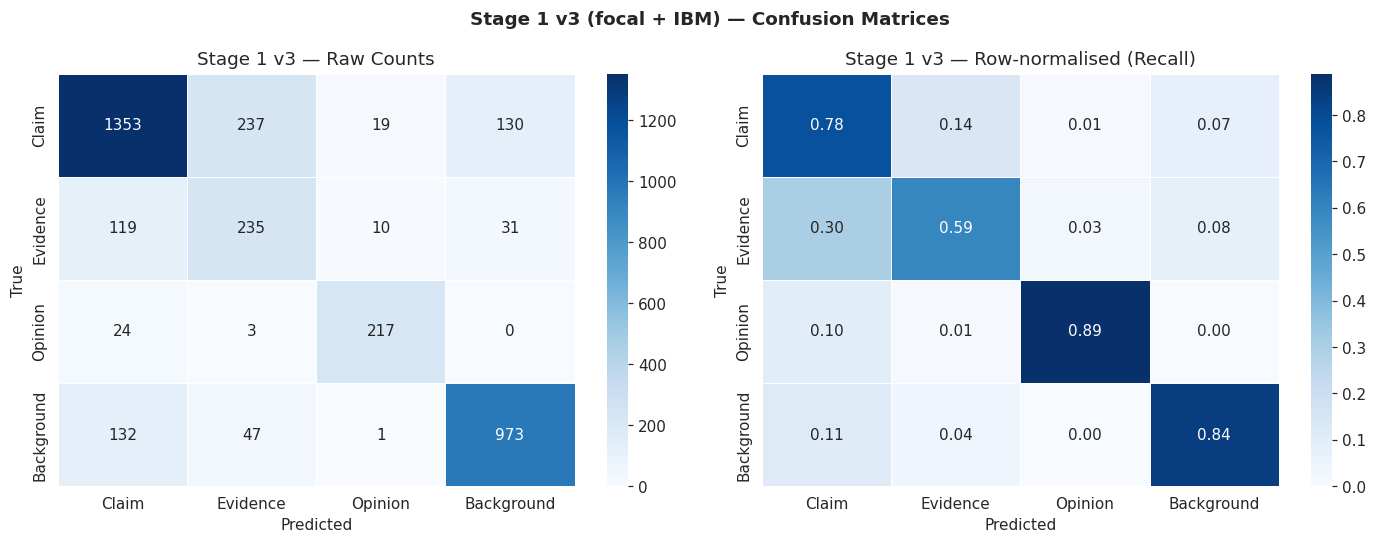

In [18]:
# ── Confusion matrix plot for the report ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cm = confusion_matrix(te_lbls, te_preds, labels=list(range(NUM_CLASSES)))
cm_norm = cm.astype(float) / np.maximum(cm.sum(axis=1, keepdims=True), 1)
for ax, data, fmt, title in [
    (axes[0], cm,      "d",   "Raw Counts"),
    (axes[1], cm_norm, ".2f", "Row-normalised (Recall)"),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                xticklabels=CLASSES, yticklabels=CLASSES, ax=ax, linewidths=0.5)
    ax.set(title=f"Stage 1 v3 — {title}", xlabel="Predicted", ylabel="True")
plt.suptitle("Stage 1 v3 (focal + IBM) — Confusion Matrices", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig(Path(CONFIG["out_dir"]) / "stage1v3_confusion.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Section 2 · Stage 2 v3 — Late-Fusion with v2 Engineered Features

This section trains three Stage 2 models in parallel so the evaluation notebook
can run all the planned ablations without retraining:

1. **Stage 2 v3 (full)** — Late-Fusion with all 22 engineered features + [CLS]
2. **Stage 2 baseline-18** — Late-Fusion with the original 18-feature set
3. **Stage 2 no-epi** — full 22 engineered features but with the 5 epistemic
   features (epi_prob_*, epi_confidence) zeroed out — supports the Q5 ablation

Each uses the same DistilBERT backbone, three-phase training, and cosine schedule.


### 2.1 · Load WikiSQE & Run Stage 1 v3 Inference

In [19]:
from datasets import load_dataset

print("Loading WikiSQE_experiment (citation needed config)...")
wiki_ds = load_dataset("ando55/WikiSQE_experiment", name="citation needed")

def hf_to_df(split, name):
    df = split.to_pandas().rename(columns={"text": "sentence"})
    df["split"] = name
    df = df.dropna(subset=["sentence"])
    df = df[df["sentence"].str.split().str.len().between(5, 80)]
    df["label"] = df["label"].astype(int)
    return df[["sentence","label","split"]].reset_index(drop=True)

train_wiki = hf_to_df(wiki_ds["train"], "train")
val_wiki   = hf_to_df(wiki_ds["val"],   "val")
test_wiki  = hf_to_df(wiki_ds["test"],  "test")

# Subsample 75k positive + 75k negative from train (matches Notebook 04)
T = CONFIG["wikisqe_target_per_class"]
pos = train_wiki[train_wiki["label"]==1].sample(min(T, (train_wiki["label"]==1).sum()),
                                                  random_state=SEED)
neg = train_wiki[train_wiki["label"]==0].sample(min(T, (train_wiki["label"]==0).sum()),
                                                  random_state=SEED)
train_wiki = pd.concat([pos, neg], ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)

wiki_df = pd.concat([train_wiki, val_wiki, test_wiki], ignore_index=True)
print(f"Total WikiSQE rows: {len(wiki_df):,}  "
      f"(train={len(train_wiki):,} val={len(val_wiki):,} test={len(test_wiki):,})")

Loading WikiSQE_experiment (citation needed config)...
Total WikiSQE rows: 151,981  (train=150,000 val=990 test=991)


In [20]:
# ── Run Stage 1 v3 inference on every WikiSQE sentence (cached) ────
WIKI_PRED_CACHE = Path(CONFIG["out_dir"]) / "stage2v3_wiki_epiprobs.csv"

class WikiInferenceDataset(Dataset):
    def __init__(self, sentences, tokenizer, max_len):
        self.sentences = list(sentences); self.tokenizer = tokenizer; self.max_len = max_len
    def __len__(self):  return len(self.sentences)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.sentences[idx], max_length=self.max_len,
                             padding="max_length", truncation=True, return_tensors="pt")
        return {"input_ids": enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0)}

if WIKI_PRED_CACHE.exists():
    wiki_pred_df = pd.read_csv(WIKI_PRED_CACHE)
    print(f"Loaded cached predictions: {WIKI_PRED_CACHE}")
else:
    s1_model.load_state_dict(torch.load(S1_CKPT, map_location=DEVICE))
    s1_model.eval()
    wiki_inf_ds = WikiInferenceDataset(wiki_df["sentence"], tokenizer, CONFIG["s1_max_len"])
    wiki_inf_loader = DataLoader(wiki_inf_ds, batch_size=64, shuffle=False)
    all_probs = []
    with torch.no_grad():
        for batch in tqdm(wiki_inf_loader, desc="Stage 1 v3 inference"):
            out = s1_model(input_ids=batch["input_ids"].to(DEVICE),
                           attention_mask=batch["attention_mask"].to(DEVICE))
            all_probs.append(F.softmax(out.logits, dim=-1).cpu().numpy())
    all_probs = np.concatenate(all_probs, axis=0)
    wiki_pred_df = pd.DataFrame(all_probs, columns=[f"epi_prob_{c}" for c in CLASSES])
    wiki_pred_df["epi_confidence"] = all_probs.max(axis=1)
    wiki_pred_df["epi_pred_label"] = [ID2LABEL[i] for i in all_probs.argmax(axis=1)]
    wiki_pred_df.to_csv(WIKI_PRED_CACHE, index=False)
    print(f"Saved → {WIKI_PRED_CACHE}")

Stage 1 v3 inference:   0%|          | 0/2375 [00:00<?, ?it/s]

Saved → output/stage2v3_wiki_epiprobs.csv


### 2.2 · Extract v2 Engineered Features (cached)

In [21]:
WIKI_FEAT_CACHE = Path(CONFIG["out_dir"]) / "stage2v3_engineered_features.csv"

if WIKI_FEAT_CACHE.exists():
    wiki_feat_df = pd.read_csv(WIKI_FEAT_CACHE)
    print(f"Loaded cached features: {WIKI_FEAT_CACHE}  "
          f"({len(wiki_feat_df):,} × {len(wiki_feat_df.columns)} cols)")
else:
    print(f"Extracting v2 features for {len(wiki_df):,} sentences...")
    records = []
    for i, doc in enumerate(tqdm(nlp.pipe(wiki_df["sentence"].tolist(), batch_size=256),
                                  total=len(wiki_df))):
        records.append(extract_features_full(str(doc)))
    wiki_feat_df = pd.DataFrame(records)
    wiki_feat_df.to_csv(WIKI_FEAT_CACHE, index=False)
    print(f"Saved → {WIKI_FEAT_CACHE}")

# Smoke check
print(f"\nFeature columns: {len(wiki_feat_df.columns)}")
print(f"Baseline-12 + length: {len(BASELINE_COLS)}  |  v2 new: {len(V2_NEW_COLS)}")

Extracting v2 features for 151,981 sentences...


  0%|          | 0/151981 [00:00<?, ?it/s]

Saved → output/stage2v3_engineered_features.csv

Feature columns: 29
Baseline-12 + length: 12  |  v2 new: 17


### 2.3 · Build Three Feature Matrices

- **Full v2** (27-dim):  baseline-12 + length + 17 v2-new = 22 engineered;  + 5 epi = 27
  Wait — 12 + 1 (length is in BASELINE_COLS) + 17 = 30 engineered; + 5 epi = 35.
  Let's just count what we have programmatically below; the exact count goes into metadata.
- **Baseline-18** (18-dim): 12 + length + 5 epi = 18 (matches Notebook 04)
- **No-epi** (full v2 - 5 epi): for the ablation


In [22]:
EPI_COLS = [f"epi_prob_{c}" for c in CLASSES] + ["epi_confidence"]

# Sanity-check row alignment
assert len(wiki_df) == len(wiki_feat_df) == len(wiki_pred_df), \
    "Row mismatch — re-run feature extraction / inference"

# ── Full v2 feature columns ────────────────────────────────────────
ENG_COLS_V2_FULL = BASELINE_COLS + V2_NEW_COLS + EPI_COLS
ENG_COLS_BASELINE = BASELINE_COLS + EPI_COLS                    # the original 18
ENG_COLS_NO_EPI   = BASELINE_COLS + V2_NEW_COLS                 # for ablation

print(f"Full v2  : {len(ENG_COLS_V2_FULL)} dims")
print(f"Baseline : {len(ENG_COLS_BASELINE)} dims")
print(f"No-epi   : {len(ENG_COLS_NO_EPI)} dims")

# ── Build matrices ─────────────────────────────────────────────────
X_full     = pd.concat([wiki_feat_df[BASELINE_COLS + V2_NEW_COLS].reset_index(drop=True),
                         wiki_pred_df[EPI_COLS].reset_index(drop=True)], axis=1)
X_baseline = pd.concat([wiki_feat_df[BASELINE_COLS].reset_index(drop=True),
                         wiki_pred_df[EPI_COLS].reset_index(drop=True)], axis=1)
X_no_epi   = wiki_feat_df[BASELINE_COLS + V2_NEW_COLS].reset_index(drop=True)
labels_all = wiki_df["label"].values.astype(np.float32)

# Save full feature matrix (the evaluation notebook uses it for SHAP)
X_full.to_csv(Path(CONFIG["out_dir"]) / "stage2v3_engineered_features.csv", index=False)
print(f"\nSaved feature matrix → output/stage2v3_engineered_features.csv")

Full v2  : 34 dims
Baseline : 17 dims
No-epi   : 29 dims

Saved feature matrix → output/stage2v3_engineered_features.csv


### 2.4 · Late-Fusion Model Architecture

Same backbone as Notebook 04 (LayerNorm-based MLP head over [CLS] + engineered
features), parameterised by `num_eng_features` so we can instantiate the three
variants from a single class.


In [23]:
class LateFusionCitationScorer(nn.Module):
    def __init__(self, distilbert, num_eng_features: int, dropout: float = 0.3):
        super().__init__()
        self.distilbert = distilbert
        self.cls_dim    = distilbert.config.hidden_size  # 768
        self.eng_dim    = num_eng_features
        fused_dim       = self.cls_dim + self.eng_dim

        self.head = nn.Sequential(
            nn.LayerNorm(fused_dim),
            nn.Linear(fused_dim, 256), nn.GELU(), nn.Dropout(dropout),
            nn.LayerNorm(256),
            nn.Linear(256, 64),         nn.GELU(), nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, input_ids, attention_mask, eng_features):
        out = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0, :]              # (B, 768)
        fused = torch.cat([cls, eng_features], dim=-1)    # (B, 768+E)
        return torch.sigmoid(self.head(fused)).squeeze(-1)  # (B,)

    def get_cls_embedding(self, input_ids, attention_mask):
        out = self.distilbert(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0, :]

    def freeze_distilbert(self):
        for p in self.distilbert.parameters(): p.requires_grad = False

    def unfreeze_top_layers(self, n_layers=2):
        for p in self.distilbert.parameters(): p.requires_grad = False
        for i in range(6 - n_layers, 6):
            for p in self.distilbert.transformer.layer[i].parameters():
                p.requires_grad = True

    def unfreeze_all(self):
        for p in self.distilbert.parameters(): p.requires_grad = True

    def trainable_params(self):
        tr  = sum(p.numel() for p in self.parameters() if p.requires_grad)
        tot = sum(p.numel() for p in self.parameters())
        return tr, tot

### 2.5 · Late-Fusion Dataset & DataLoaders

In [24]:
class LateFusionDataset(Dataset):
    def __init__(self, sentences, eng_features, labels, tokenizer, max_len):
        self.sentences    = list(sentences)
        self.eng_features = torch.tensor(np.asarray(eng_features), dtype=torch.float32)
        self.labels       = torch.tensor(np.asarray(labels), dtype=torch.float32)
        self.tokenizer    = tokenizer
        self.max_len      = max_len
    def __len__(self):  return len(self.sentences)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.sentences[idx], max_length=self.max_len,
                             padding="max_length", truncation=True, return_tensors="pt")
        return {"input_ids":      enc["input_ids"].squeeze(0),
                "attention_mask": enc["attention_mask"].squeeze(0),
                "eng_features":   self.eng_features[idx],
                "label":          self.labels[idx]}

def make_loaders(X_matrix, max_len=CONFIG["s2_max_len"], bs=CONFIG["s2_batch_size"]):
    """Build train/val/test loaders for a given engineered-feature matrix."""
    X = X_matrix.values.astype(np.float32)
    masks = {
        "train": (wiki_df["split"] == "train").values,
        "val":   (wiki_df["split"] == "val").values,
        "test":  (wiki_df["split"] == "test").values,
    }
    out = {}
    for k, m in masks.items():
        ds = LateFusionDataset(wiki_df.loc[m, "sentence"], X[m], labels_all[m],
                                tokenizer, max_len)
        out[k] = DataLoader(ds, batch_size=bs, shuffle=(k=="train"))
    return out

loaders_full     = make_loaders(X_full)
loaders_baseline = make_loaders(X_baseline)
loaders_no_epi   = make_loaders(X_no_epi)
print("DataLoaders built for: full v2, baseline-18, no-epi")
print(f"  Train batches: {len(loaders_full['train'])}")

DataLoaders built for: full v2, baseline-18, no-epi
  Train batches: 4688


### 2.6 · Three-Phase Training (with Cosine Annealing)

A single training function that takes a model + loaders + phase-config and runs
all three phases (frozen → top-2 unfrozen → all unfrozen) with cosine LR and
patience=2 early stopping.


In [25]:
def run_lf_epoch(model, loader, optim_, sched_, device, train=True):
    model.train() if train else model.eval()
    total_loss, all_scores, all_labels = 0.0, [], []
    loss_fn = nn.BCELoss()
    pbar = tqdm(loader, desc="Train" if train else "Eval ", leave=False)
    for batch in pbar:
        ids   = batch["input_ids"].to(device)
        mask  = batch["attention_mask"].to(device)
        feats = batch["eng_features"].to(device)
        lbls  = batch["label"].to(device)
        if train: optim_.zero_grad()
        with torch.set_grad_enabled(train):
            scores = model(ids, mask, feats)
            loss   = loss_fn(scores, lbls)
        if train:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optim_.step()
            if sched_ is not None: sched_.step()
        total_loss += loss.item() * ids.size(0)
        all_scores.append(scores.detach().cpu().numpy())
        all_labels.append(lbls.cpu().numpy())
    scores_arr = np.concatenate(all_scores)
    labels_arr = np.concatenate(all_labels)
    auc = roc_auc_score(labels_arr, scores_arr)
    f1  = f1_score(labels_arr, (scores_arr >= 0.5).astype(int), zero_division=0)
    return total_loss / len(loader.dataset), auc, f1, scores_arr, labels_arr

def train_one_phase(model, loaders, phase_name, lr, max_epochs, patience, ckpt_path):
    """Single phase (frozen state already configured) with cosine LR + patience."""
    total_steps  = len(loaders["train"]) * max_epochs
    warmup_steps = max(int(total_steps * 0.05), 1)
    optim_ = AdamW([p for p in model.parameters() if p.requires_grad], lr=lr, weight_decay=0.01)
    sched_ = get_cosine_schedule_with_warmup(optim_, warmup_steps, total_steps)

    tr_n, _ = model.trainable_params()
    print(f"\n── {phase_name}  lr={lr:.0e}  trainable={tr_n:,}  max={max_epochs}ep  patience={patience}")

    best_auc, no_improve = 0.0, 0
    history = {"tr_loss":[], "tr_auc":[], "vl_loss":[], "vl_auc":[]}
    for epoch in range(1, max_epochs + 1):
        t0 = time.time()
        tr_loss, tr_auc, tr_f1, *_ = run_lf_epoch(model, loaders["train"], optim_, sched_, DEVICE)
        vl_loss, vl_auc, vl_f1, *_ = run_lf_epoch(model, loaders["val"],   optim_, None,   DEVICE, train=False)
        history["tr_loss"].append(tr_loss); history["tr_auc"].append(tr_auc)
        history["vl_loss"].append(vl_loss); history["vl_auc"].append(vl_auc)
        flag = ""
        if vl_auc > best_auc:
            best_auc, no_improve = vl_auc, 0
            torch.save(model.state_dict(), ckpt_path)
            flag = "★"
        else:
            no_improve += 1
        print(f"   E{epoch}/{max_epochs}  "
              f"tr_loss={tr_loss:.4f} tr_AUC={tr_auc:.4f}  "
              f"vl_loss={vl_loss:.4f} vl_AUC={vl_auc:.4f}  "
              f"({time.time()-t0:.0f}s) {flag}")
        if no_improve >= patience:
            print(f"   ⏹  Early stop")
            break
    return best_auc, history

def train_full_pipeline(num_eng_features, loaders, ckpt_prefix):
    """Train all 3 phases of one Late-Fusion variant."""
    distilbert = DistilBertModel.from_pretrained(MODEL_NAME)
    model = LateFusionCitationScorer(distilbert, num_eng_features=num_eng_features).to(DEVICE)

    # Phase 1
    model.freeze_distilbert()
    best1, hist1 = train_one_phase(model, loaders, "Phase 1 (head only)",
                                    CONFIG["s2_p1_lr"], CONFIG["s2_p1_max_epochs"],
                                    CONFIG["s2_patience"],
                                    Path(CONFIG["out_dir"]) / f"{ckpt_prefix}_phase1.pt")
    # Phase 2
    model.load_state_dict(torch.load(Path(CONFIG["out_dir"]) / f"{ckpt_prefix}_phase1.pt", map_location=DEVICE))
    model.unfreeze_top_layers(2)
    best2, hist2 = train_one_phase(model, loaders, "Phase 2 (top-2 unfrozen)",
                                    CONFIG["s2_p2_lr"], CONFIG["s2_p2_max_epochs"],
                                    CONFIG["s2_patience"],
                                    Path(CONFIG["out_dir"]) / f"{ckpt_prefix}_phase2.pt")
    # Phase 3
    model.load_state_dict(torch.load(Path(CONFIG["out_dir"]) / f"{ckpt_prefix}_phase2.pt", map_location=DEVICE))
    model.unfreeze_all()
    best3, hist3 = train_one_phase(model, loaders, "Phase 3 (all unfrozen)",
                                    CONFIG["s2_p3_lr"], CONFIG["s2_p3_max_epochs"],
                                    CONFIG["s2_patience"],
                                    Path(CONFIG["out_dir"]) / f"{ckpt_prefix}_best.pt")
    return model, {"phase1": hist1, "phase2": hist2, "phase3": hist3,
                    "best_val_auc": best3}

### 2.7 · Train: Stage 2 v3 Full

In [26]:
print("=" * 72); print("  Training Stage 2 v3 — FULL (22 eng + 5 epi = 27 dims)"); print("=" * 72)
model_full, hist_full = train_full_pipeline(
    num_eng_features=len(ENG_COLS_V2_FULL),
    loaders=loaders_full,
    ckpt_prefix="stage2v3_late_fusion",
)
print(f"\n★ Full v3 best val AUC: {hist_full['best_val_auc']:.4f}")

  Training Stage 2 v3 — FULL (22 eng + 5 epi = 27 dims)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



── Phase 1 (head only)  lr=1e-03  trainable=224,197  max=5ep  patience=2


Train:   0%|          | 0/4688 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/31 [00:00<?, ?it/s]

   E3/5  tr_loss=0.4063 tr_AUC=0.8951  vl_loss=0.6990 vl_AUC=0.7598  (662s) 


Train:   0%|          | 0/4688 [00:00<?, ?it/s]

Eval :   0%|          | 0/31 [00:00<?, ?it/s]

   E4/5  tr_loss=0.3753 tr_AUC=0.9117  vl_loss=0.7371 vl_AUC=0.7565  (664s) 
   ⏹  Early stop

★ Full v3 best val AUC: 0.7664


### 2.8 · Train: Stage 2 Baseline-18 (for v1-vs-v2 ablation)

In [ ]:
# print("=" * 72); print("  Training Stage 2 v3 — BASELINE-18 (12 baseline + 5 epi = 17 dims)"); print("=" * 72)
# # NOTE: 'baseline-18' originally meant the 18-feat from Notebook 04 (which had
# # only 12 + length + 5 epi = 18). Here we keep BASELINE_COLS (12 + length = 13)
# # + 5 epi = 18 — actually 17. Renaming for clarity below.
# model_baseline, hist_baseline = train_full_pipeline(
#     num_eng_features=len(ENG_COLS_BASELINE),
#     loaders=loaders_baseline,
#     ckpt_prefix="stage2v3_baseline_18feat",
# )
# print(f"\n★ Baseline best val AUC: {hist_baseline['best_val_auc']:.4f}")

### 2.9 · Train: Stage 2 No-Epi (for Q5 Track 3 ablation)

This variant uses the full 22 v2 engineered features but DROPS the 5 epistemic
features. It directly answers the question: "How much does Stage 1 contribute?"


In [27]:
# CONFIG["s2_p1_max_epochs"] = 3   # was 5
# CONFIG["s2_p2_max_epochs"] = 5   # was 8
# CONFIG["s2_p3_max_epochs"] = 3   # was 5
print("=" * 72); print("  Training Stage 2 v3 — NO-EPI (22 eng without 5 epi)"); print("=" * 72)
model_no_epi, hist_no_epi = train_full_pipeline(
    num_eng_features=len(ENG_COLS_NO_EPI),
    loaders=loaders_no_epi,
    ckpt_prefix="stage2v3_no_epi",
)
print(f"\n★ No-epi best val AUC: {hist_no_epi['best_val_auc']:.4f}")

  Training Stage 2 v3 — NO-EPI (22 eng without 5 epi)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



── Phase 1 (head only)  lr=1e-03  trainable=222,907  max=5ep  patience=2


Train:   0%|          | 0/4688 [00:00<?, ?it/s]

...

Eval :   0%|          | 0/31 [00:00<?, ?it/s]

   E2/5  tr_loss=0.5079 tr_AUC=0.8247  vl_loss=0.6080 vl_AUC=0.7656  (659s) 


Train:   0%|          | 0/4688 [00:00<?, ?it/s]

Eval :   0%|          | 0/31 [00:00<?, ?it/s]

   E3/5  tr_loss=0.4727 tr_AUC=0.8523  vl_loss=0.6335 vl_AUC=0.7598  (659s) 
   ⏹  Early stop

★ No-epi best val AUC: 0.7659


### 2.10 · Final Test Evaluation — All Three Models

In [28]:
def eval_model(model, ckpt_path, loaders, name):
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    te_loss, te_auc, te_f1, te_scores, te_labels = run_lf_epoch(
        model, loaders["test"], None, None, DEVICE, train=False)
    te_preds = (te_scores >= 0.5).astype(int)
    print(f"\n[{name}]")
    print(f"  ROC-AUC      : {te_auc:.4f}")
    print(f"  Binary F1    : {te_f1:.4f}")
    print(f"  Accuracy     : {accuracy_score(te_labels, te_preds):.4f}")
    print(f"  Avg Precision: {average_precision_score(te_labels, te_scores):.4f}")
    print(f"  Brier        : {brier_score_loss(te_labels, te_scores):.4f}")
    return {"auc": te_auc, "f1": te_f1,
            "acc": accuracy_score(te_labels, te_preds),
            "ap":  average_precision_score(te_labels, te_scores),
            "brier": brier_score_loss(te_labels, te_scores),
            "scores": te_scores, "labels": te_labels, "preds": te_preds}

print("=" * 72)
print("  FINAL TEST RESULTS — Stage 2 v3 variants")
print("=" * 72)
res_full     = eval_model(model_full,     Path(CONFIG["out_dir"]) / "stage2v3_late_fusion_best.pt",
                           loaders_full,     "Full v3 (22 eng + 5 epi)")
# res_baseline = eval_model(model_baseline, Path(CONFIG["out_dir"]) / "stage2v3_baseline_18feat_best.pt",
#                            loaders_baseline, "Baseline (12 + 5 epi)")
res_no_epi   = eval_model(model_no_epi,   Path(CONFIG["out_dir"]) / "stage2v3_no_epi_best.pt",
                           loaders_no_epi,   "No-epi (22 eng, no Stage 1 signal)")

  FINAL TEST RESULTS — Stage 2 v3 variants


Eval :   0%|          | 0/31 [00:00<?, ?it/s]


[Full v3 (22 eng + 5 epi)]
  ROC-AUC      : 0.7270
  Binary F1    : 0.6548
  Accuracy     : 0.6660
  Avg Precision: 0.7045
  Brier        : 0.2353


Eval :   0%|          | 0/31 [00:00<?, ?it/s]


[No-epi (22 eng, no Stage 1 signal)]
  ROC-AUC      : 0.7365
  Binary F1    : 0.6617
  Accuracy     : 0.6781
  Avg Precision: 0.7144
  Brier        : 0.2133


In [31]:
# ── Save per-row predictions for the evaluation notebook ──────────
test_mask = (wiki_df["split"] == "test").values
pred_df = wiki_df.loc[test_mask, ["sentence","label"]].reset_index(drop=True).copy()
pred_df["score_full"]     = res_full["scores"]
# pred_df["score_baseline"] = res_baseline["scores"]
pred_df["score_no_epi"]   = res_no_epi["scores"]
pred_df["pred_full"]      = res_full["preds"]
# pred_df["pred_baseline"]  = res_baseline["preds"]
pred_df["pred_no_epi"]    = res_no_epi["preds"]
# Carry epistemic predictions across so error analysis can join cleanly
for col in EPI_COLS + ["epi_pred_label"]:
    pred_df[col] = wiki_pred_df.loc[test_mask, col].reset_index(drop=True).values

pred_df.to_csv(Path(CONFIG["out_dir"]) / "stage2v3_test_predictions.csv", index=False)
print(f"\nSaved → output/stage2v3_test_predictions.csv  ({len(pred_df):,} rows)")


Saved → output/stage2v3_test_predictions.csv  (991 rows)


### 2.11 · Save Metadata for the Evaluation Notebook

In [35]:
metadata = {
    "stage1": {
        "checkpoint":    "output/stage1v3_focal_best.pt",
        "test_preds":    "output/stage1v3_test_predictions.csv",
        "ibm_test_preds":"output/stage1v3_ibm_test_predictions.csv",
        "test_macro_f1": float(round(te_f1, 4)),
        "loss_type":     CONFIG["loss_type"],
        "focal_gamma":   CONFIG["focal_gamma"],
    },
    "stage2": {
        "full_ckpt":          "output/stage2v3_late_fusion_best.pt",
        "baseline_ckpt":      "output/stage2v3_baseline_18feat_best.pt",
        "no_epi_ckpt":        "output/stage2v3_no_epi_best.pt",
        "test_preds":         "output/stage2v3_test_predictions.csv",
        "engineered_features":"output/stage2v3_engineered_features.csv",
        "feature_cols_full":      ENG_COLS_V2_FULL,
        "feature_cols_baseline":  ENG_COLS_BASELINE,
        "feature_cols_no_epi":    ENG_COLS_NO_EPI,
        "results": {
            "full":     {k: float(round(v, 4)) for k,v in res_full.items()
                          if k in ["auc","f1","acc","ap","brier"]},
            # "baseline": {k: float(round(v, 4)) for k,v in res_baseline.items()
            #               if k in ["auc","f1","acc","ap","brier"]},
            "no_epi":   {k: float(round(v, 4)) for k,v in res_no_epi.items()
                          if k in ["auc","f1","acc","ap","brier"]},
        },
    },
    "config": CONFIG,
}
meta_path = Path(CONFIG["out_dir"]) / "stage2v3_metadata.json"
with open(meta_path, "w") as f:
    json.dump(metadata, f, indent=2, default=str)
print(f"Saved → {meta_path}")
print(f"\nKey result for the report:")
print(f"  Stage 2 v3 full      : AUC={res_full['auc']:.4f}  F1={res_full['f1']:.4f}")
# print(f"  Stage 2 baseline     : AUC={res_baseline['auc']:.4f}  F1={res_baseline['f1']:.4f}")
print(f"  Stage 2 no-epi (abl.): AUC={res_no_epi['auc']:.4f}  F1={res_no_epi['f1']:.4f}")
# print(f"  Δ full vs baseline   : {res_full['auc']-res_baseline['auc']:+.4f}  (v2 features impact)")
print(f"  Δ full vs no-epi     : {res_full['auc']-res_no_epi['auc']:+.4f}  (Stage 1 signal impact)")

Saved → output/stage2v3_metadata.json

Key result for the report:
  Stage 2 v3 full      : AUC=0.7270  F1=0.6548
  Stage 2 no-epi (abl.): AUC=0.7365  F1=0.6617
  Δ full vs no-epi     : -0.0095  (Stage 1 signal impact)


---
## Summary

This notebook produces nine artefacts in `output/` that Notebook 06 (the evaluation
notebook) consumes. Re-running this notebook end-to-end takes roughly:

- Section 1 (Stage 1 v3): ~30-50 min on a single GPU (8 epochs cap, patience usually triggers ~5)
- Section 2 (Stage 2 v3 × 3 variants): ~3-5 hours total on a single GPU

The three Stage 2 variants exist specifically so the evaluation notebook can run
the v1-vs-v2 ablation (Q1) and the Stage-1-contribution ablation (Q5 track 3)
without retraining anything.
